# Ill-Conditioned Regression Problems

In the previous notebook, we have learned the core working processes of SINDy: numerically differentiating time-series data, constructing a candidate function library and application of sparse regression algorithm with the appropriate sparsification hyperparameter. However, as it was alluded to in the previous notebook, depending on the specific dataset and constructed library, we may be faced with an ill-conditioned regression problem. In this tutorial, we seek to tackle common ill-conditioning problems.

In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import warnings
from IPython.display import display, Math

from sindy.odes import duffing
from sindy.ivp_solvers import rk4
from sindy.library import poly_lib
from sindy.optimizer import stlsq, stridge
from sindy.plot_utils import init_plt_format
from sindy.utils import set_seed, print_latex_eqn

warnings.filterwarnings('ignore', category=RuntimeWarning)
init_plt_format()
set_seed(0)

# Methods to Help Tackle Ill-Conditioning

## Ridge Regression

In certain regression problems with highly correlated candidate functions such as in PDEs, the candidate function library may become highly ill-conditioned as highlighted in ([Rudy et al, 2017](https://www.science.org/doi/full/10.1126/sciadv.1602614)). In addition to the L0 regularization of sparse regression, a L2 norm ridge regression may be added such that

$$\min_{\xi_i} || \dot{X_i} - \Theta(X) \xi_i ||^2 + \lambda ||\xi_i||_0 + \gamma || \xi_i ||^2_2,$$

which has a convex solution of

$$\xi_i = (\Theta^T(X) \Theta(X) + \gamma I)^{-1} \Theta^T(X) \dot{X_i}.$$

The main motivation of ridge regression is the addition of a small $\gamma$ to the diagonals of $\Theta^T(X) \Theta(X)$ which improves the conditioning of the matrix. This is also known as Tikhonov regularization.

Let's look at an example of a Duffing oscillator with the parameters

$$
\begin{aligned}
    \dot{x}_1 &= x_2 \\
    \dot{x}_2 &= - x_1 + 0.1 x_1^3 - 0.1 x_2
\end{aligned}
$$

The system is similar to a damped linear oscillator for small values of $x$, but the system becomes unstable if the initial condition is placed sufficiently far away from the origin as illustrated in the phase diagram below.

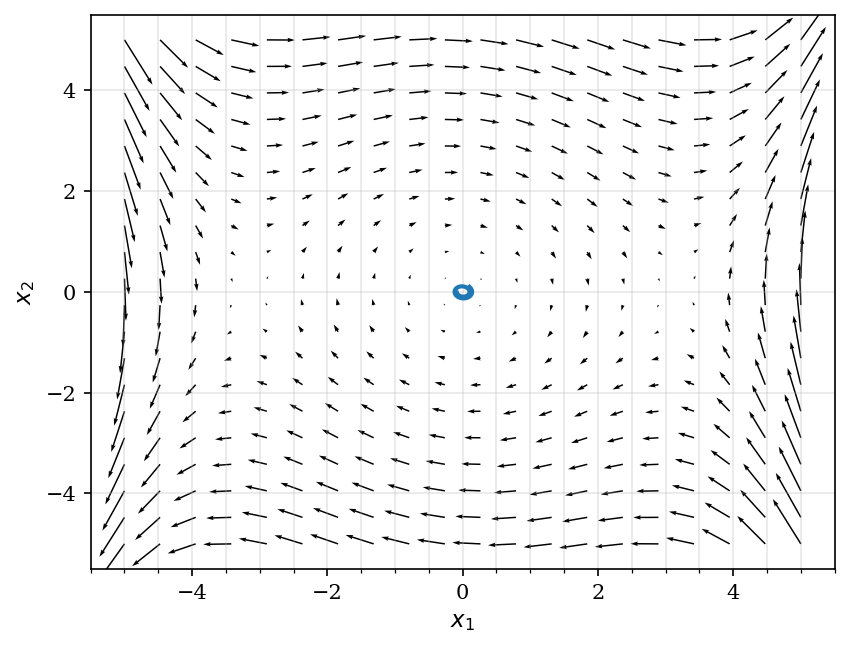

In [2]:
# Define the initial condition of the example trajectory
x0 = np.array([0.1, 0.1])

# Define Duffing oscillator parameters
duffing_params = [0.1, 1.0, -0.1]

# Define visual grid discretization
grid_pts: int = 20

x1 = np.linspace(-5, 5, grid_pts)
x2 = np.linspace(-5, 5, grid_pts)
X1, X2 = np.meshgrid(x1, x2)

# Initialise xdot matrix for phase space visualization
X1_dot = np.empty(X1.shape)
X2_dot = np.empty(X2.shape)

# Compute all time derivatives
for idx1, x1_ij in enumerate(x1):
    for idx2, x2_ij in enumerate(x2):
        xdot = duffing(0, np.array([x1_ij, x2_ij]), *duffing_params)
        X1_dot[idx2, idx1] = xdot[0]
        X2_dot[idx2, idx1] = xdot[1]

# Compute sample trajectory
t, x = rk4(duffing, 10.0, x0, args=duffing_params)

# Plotting
plt.quiver(X1, X2, X1_dot, X2_dot, width=0.002)
plt.plot(x[:,0], x[:,1])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$');

If we use a 5th order polynomial library, we would fail to recover the system using STLSQ when using a $\lambda = 0.01$.

In [3]:
xdot = ps.FiniteDifference()._differentiate(x, t)
lib, lib_names = poly_lib(x, 5, False)
xi = stlsq(lib, xdot)

print(f"The condition number of library matrix is {np.linalg.cond(lib):.3e}.")
display(Math(print_latex_eqn(xi, lib_names[:2], lib_names)))

The condition number of library matrix is 1.946e+08.


<IPython.core.display.Math object>

Unless we know the exact sparsification hyperparameter to use (which is just under 0.1), we will often recover the incorrect system. However, if we use STRidge, we may recover a linear damped oscillator system.

In [4]:
xi = stridge(lib, xdot, l2_norm=1e-3)

display(Math(print_latex_eqn(xi, lib_names[:2], lib_names)))

<IPython.core.display.Math object>

This produces a system closer to the true equation, and relaxes the stringent requirement for finding an exact $\lambda$ value. However, one should be careful not to use an excessively high $\gamma$ L2 regularization strength, as this may yield an inaccurate model despite having the correct sparsity structure.


## Library Normalization

Another likely cause of ill-conditioned matrix is poorly scaled library matrix. Alternatively, we may improve the conditioning of the regression problem by normalizing the library matrix. This may occur not only because of highly different scales between state variables, but also dependent on the specific library used. For instance, if we have a polynomial library with both linear terms and a high degree term such as $x^{10}$, the magnitude of the library matrix $\Theta$ can have highly different scales depending for $x >> 1$.

We may rescale the library matrix using
$$\tilde{\Theta}(X) = \Theta(X) N^{-1},$$

where
$$N = \text{diag}(||\theta_1|| \dots ||\theta_l||).$$

Then the regression problem becomes
$$\dot{X}_j = \Theta(X) \xi_j = \Theta(X) N^{-1} N \xi_j = \tilde{\Theta}(X) \tilde{\xi}_j.$$

Finally, to recover the true coefficients
$$\xi_j = N^{-1} \tilde{\xi}_j.$$

Now let us apply this back to the Duffing oscillator example:

In [5]:
norm_inv = np.linalg.inv(np.linalg.norm(lib, axis=0) * np.eye(lib.shape[1]))
lib_norm = lib @ norm_inv
xi_norm = stlsq(lib_norm, xdot)
xi = norm_inv @ xi_norm

print(f"The condition number of library matrix is {np.linalg.cond(lib_norm):.3e}.")
display(Math(print_latex_eqn(xi, lib_names[:2], lib_names)))

The condition number of library matrix is 8.079e+04.


<IPython.core.display.Math object>

Despite using the same 5th order polynomial library, we obtain a library matrix condition number orders of magnitudes lower than the previous attempt without normalization.

## Adding More Data

As with many machine learning methods, the performance of a learned model hinges on the quality and quantity of data. If the training dataset does not contain the appropriate dynamics, the model simply has nothing to learn from. Whilst SINDy requires significantly less data to train compared to deep learning type methods, it requires data that encompasses all key dynamics.

For instance, here we must sample using an initial condition sufficiently far away from the origin where the cubic non-linearity becomes significant.

In [6]:
# Select a new initial condition and generate a new trajectory
x0 = np.array([1, 1])
t, x = rk4(duffing, 10.0, x0, args=duffing_params)

# Fit a SINDy model
xdot = ps.FiniteDifference()._differentiate(x, t)
lib, lib_names = poly_lib(x, 5, False)
xi = stlsq(lib, xdot)

print(f"The condition number of library matrix is {np.linalg.cond(lib):.3e}.")
display(Math(print_latex_eqn(xi, lib_names[:2], lib_names)))

The condition number of library matrix is 1.161e+04.


<IPython.core.display.Math object>

Sampling away from the origin improves the conditioning of the library matrix $\Theta(X)$ as this reduces the effects of multicollinearity, even without using library normalization.

Furthermore, adding more data may not just refer to a longer time span of the time-series data, but also finer time step (and spatial step for spatiotemporal systems) resolution. We can see the effects of this by fitting the model on subsampled dataset here.

In [7]:
# Fit a SINDy model on subsampled data
subsample_interval = 6
xdot = ps.FiniteDifference()._differentiate(
    x[::subsample_interval], t[::subsample_interval]
)
lib, lib_names = poly_lib(x[::subsample_interval], 5, False)
xi = stlsq(lib, xdot)

print(f"The condition number of library matrix is {np.linalg.cond(lib):.3e}.")
display(Math(print_latex_eqn(xi, lib_names[:2], lib_names)))

The condition number of library matrix is 1.167e+04.


<IPython.core.display.Math object>

Lower temporal resolution data heavily affects the accuracy of the computed time derivative data. Though this can be mitigated to a certain extent by using a higher order accuracy for finite difference, assuming the data is not contaminated with noise.

Therefore, when faced with ill-conditioned regression problems, one should:
* Begin with a small candidate function library using prior knowledge of the system, expanding it only if necessary to capture key dynamics.
* Use L2 regularizer and/or matrix normalization to improve matrix conditioning.
* Include additional data points from different initial conditions.

Note that the `STLSQ` optimizer from PySINDy uses ridge regression by default.